   Edited: Henry CH Yeung
   
   Author: Ankit Kariryaa, University of Bremen

### Getting started
Define the paths to the dataset and trained models in the `notebooks/config/UNetTraining.py` file.  

In [1]:
import tensorflow as tf
import numpy as np

get_ipython().run_line_magic('env', 'SM_FRAMEWORK=tf.keras')
import segmentation_models as sm
sm.set_framework('tf.keras')

from PIL import Image
import rasterio
import imgaug as ia
from imgaug import augmenters as iaa
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import imageio
import os
import time
import rasterio.warp             # Reproject raster samples
from functools import reduce
from tensorflow.keras.models import load_model

from core.UNet import UNet
from core.losses import tversky, focal_tversky
from core.optimizers import adaDelta, adagrad, adam, nadam
from core.frame_info import FrameInfo
from core.dataset_generator import DataGenerator
from core.split_frames import split_dataset
from core.visualize import display_images
from segmentation_models.losses import JaccardLoss, DiceLoss, CategoricalCELoss
from segmentation_models.metrics import IOUScore, FScore, Precision, Recall


import json
from sklearn.model_selection import train_test_split

get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt  # plotting tools
import matplotlib.patches as patches
from matplotlib.patches import Polygon

import warnings                  # ignore annoying warnings
warnings.filterwarnings("ignore")
import logging
logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

get_ipython().run_line_magic('reload_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

print('Tensorflow version:', tf.__version__)
print('Num GPU available:', len(tf.config.list_physical_devices('GPU')))

env: SM_FRAMEWORK=tf.keras
Segmentation Models: using `tf.keras` framework.
Tensorflow version: 2.4.1
Num GPU available: 1


In [2]:
# Required configurations (including the input and output paths) are stored in a separate file (such as config/UNetTraining.py)
# Please provide required info in the file before continuing with this notebook. 
 
from config import FineTuning
# In case you are using a different folder name such as configLargeCluster, then you should import from the respective folder 
# Eg. from configLargeCluster import UNetTraining
config = FineTuning.Configuration()

In [3]:
# Load a pretrained model
OPTIMIZER = adam
LOSS = focal_tversky
trained_model_path = os.path.join(config.trained_model_dir, config.trained_model_name+config.model_file_type)
model = load_model(trained_model_path, custom_objects={'ftversky': focal_tversky}, compile=False)
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=[DiceLoss(class_indexes=0), JaccardLoss(class_indexes=0), FScore(class_indexes=0, threshold=0.5), IOUScore(class_indexes=0, threshold=0.5), Precision(class_indexes=0, threshold=0.5), Recall(class_indexes=0, threshold=0.5)])
model.summary() # Top layer architecture
# model.get_layer('model').summary() # Submodel architecture
current_lr = tf.keras.backend.get_value(OPTIMIZER.learning_rate)
new_lr = current_lr * 5
print(f'Current learning rate: {current_lr}')

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 256, 256, 4)]     0         
_________________________________________________________________
conv2d (Conv2D)              (None, 256, 256, 3)       15        
_________________________________________________________________
model (Functional)           (None, None, None, 1)     37468673  
Total params: 37,468,688
Trainable params: 37,293,968
Non-trainable params: 174,720
_________________________________________________________________
Current learning rate: 9.999999747378752e-05


In [5]:
# The first few layers learn very simple and generic features that generalize to almost all types of images. As you go higher
# up, the features are increasingly more specific to the dataset on which the model was trained. The goal of fine-tuning is to 
# adapt these specialized features to work with the new dataset, rather than overwrite the generic learning.


#### FREEZE (CERTAIN) LAYERS ####
# Unfreeze the model and set the bottom layers to be un-trainable. Then, recompile the model (necessary for these changes to take effect), and resume training.
# Check how many layers are in the base model
print("Number of layers in the base model: ", len(model.get_layer('model').layers))

# Fine-tune from this layer onwards
fine_tune_at = config.start_trainable


for layer in model.get_layer('model').layers[:fine_tune_at]:
  layer.trainable = False

# Freeze all the layers before the `fine_tune_at` layer
for layer in model.get_layer('model').layers[:fine_tune_at]:
  layer.trainable = False
print(f"Number of Trainable Layers: {len(model.trainable_variables)}")


#### ADJUST LEARNING RATE ####
# As you are training a much larger model and want to readapt the pretrained weights, it is important to use a lower learning rate at this stage. Otherwise, your model could overfit very quickly.
tf.keras.backend.set_value(OPTIMIZER.learning_rate, new_lr)
print(f'Changed learning rate from {current_lr} to {new_lr}')

Number of layers in the base model:  610
Number of Trainable Layers: 538
Changed learning rate from 9.999999747378752e-05 to 0.0004999999873689376


In [18]:
# Recompile model
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=[DiceLoss(class_indexes=0), JaccardLoss(class_indexes=0), FScore(class_indexes=0, threshold=0.5), IOUScore(class_indexes=0, threshold=0.5), Precision(class_indexes=0, threshold=0.5), Recall(class_indexes=0, threshold=0.5)])

In [4]:
import random

# Read all images/frames into memory
frames_train = []
frames_val = []

def build_frame_list(baseDir, subsample=False):
    frames = []
    
    all_files = os.listdir(baseDir)
    all_files_ndvi = [fn for fn in all_files if fn.startswith(config.ndvi_fn) and fn.endswith(config.image_type)]
#     all_files_ndvi = [fn for fn in all_files if fn.startswith(config.ndvi_fn) and fn.endswith(config.image_type)]
    
    if subsample:
        # Randomly select a fraction of files with a fixed seed
        random.seed(config.seed)
        selected_files = random.sample(all_files_ndvi, int(len(all_files_ndvi) * config.subsample_frac))
    else:
        selected_files = all_files_ndvi

    for i, fn in enumerate(selected_files):
        ndvi_img = rasterio.open(os.path.join(baseDir, fn))
        r_img = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.r_fn)))
        g_img = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.g_fn)))
        b_img = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.b_fn)))
        n_img = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.n_fn)))
#         print(fn)
        read_ndvi_img = ndvi_img.read()
        if not np.isnan(read_ndvi_img).all() and np.any(read_ndvi_img): # filter dataframe with NaN or all zeros
            read_r_img = r_img.read()
            read_g_img = g_img.read()
            read_b_img = b_img.read()
            read_n_img = n_img.read()
            comb_img = np.concatenate((read_ndvi_img, read_r_img, read_g_img, read_b_img, read_n_img), axis=0)
            comb_img = np.transpose(comb_img, axes=(1,2,0)) #Channel at the end
            annotation_im = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.annotation_fn)))
            annotation = annotation_im.read(1)
    #         if np.any(annotation): # remove all empty label dataframes
            weight_im = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.weight_fn)))
            weight = weight_im.read(1)
            f = FrameInfo(comb_img, annotation, weight)
            frames.append(f)
    return frames

frames_train_BASE = build_frame_list(config.base_dir_train_BASE, subsample=True)
frames_val_BASE = build_frame_list(config.base_dir_val_BASE, subsample=True)
frames_train_FT = build_frame_list(config.base_dir_train_FT, subsample=False)
frames_val_FT = build_frame_list(config.base_dir_val_FT, subsample=False)

frames_train = frames_train_BASE + frames_train_FT
frames_val = frames_val_BASE + frames_val_FT

# frames_random = frames_train + frames_val
print(f'Built {len(frames_train)} of training frames and {len(frames_val)} of validation frames')

Built 1548 of training frames and 266 of validation frames


In [5]:
# training_frames, validation_frames, testing_frames  = split_dataset(frames_random, config.frames_json, config.patch_dir, test_size=config.test_ratio, val_size=config.val_ratio)
training_frames = list(range(len(frames_train)))
validation_frames = list(range(len(frames_val)))

annotation_channels = config.input_label_channel + config.input_weight_channel
train_generator = DataGenerator(config.input_image_channel, config.patch_size, training_frames, frames_train, annotation_channels, augmenter = 'iaa').random_generator(config.BATCH_SIZE, normalize=config.normalize, BACKBONE=config.PREPROCESS)
val_generator = DataGenerator(config.input_image_channel, config.patch_size, validation_frames, frames_val, annotation_channels, augmenter= None).random_generator(config.BATCH_SIZE, normalize=config.normalize, BACKBONE=config.PREPROCESS)
# test_generator = DataGenerator(config.input_image_channel, config.patch_size, testing_frames, frames_random, annotation_channels, augmenter= None).random_generator(config.BATCH_SIZE, normalize=config.normalize, BACKBONE=config.PREPROCESS)

Colored option is triggered. This plots both true color and false color image. Make sure you arrange the bands to R,G,B,NIR.


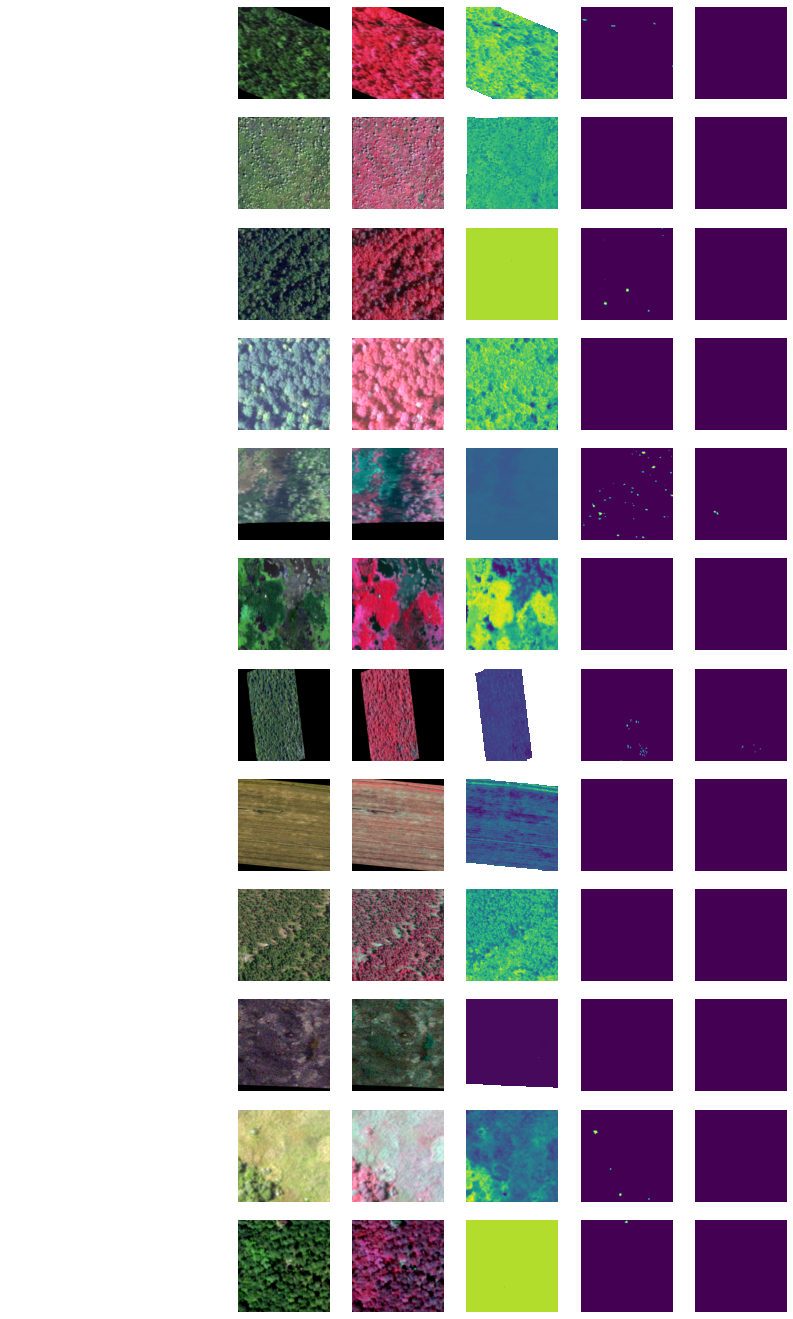

In [31]:
# for _ in range(1):
#     train_images, real_label = next(train_generator)
# #     print(train_images.shape, real_label.shape)
#     ann = real_label[:,:,:,0]
#     wei = real_label[:,:,:,1]
#     #overlay of annotation with boundary to check the accuracy
#     #5 images in each row are: pan, ndvi, annotation, weight(boundary), overlay of annotation with weight
#     overlay = ann + wei
#     overlay = overlay[:,:,:,np.newaxis]
#     ndvi = (train_images[...,3] - train_images[...,0]) / (train_images[...,3] + train_images[...,0])
#     ndvi = ndvi[...,np.newaxis]
#     display_images(np.concatenate((train_images[...,], ndvi, real_label), axis = -1), colored=True)
# # print(np.max(train_images[...,[1]]))
# # print(np.isnan(train_images).any())

In [32]:
# # Experimenting: Convert dataGenerator to tf.Data type for maximizing pipeline efficiency
# # https://medium.com/@acordier/tf-data-dataset-generators-with-parallelization-the-easy-way-b5c5f7d2a18
# AUTOTUNE = tf.data.AUTOTUNE
# def mapFunc(x, y):
#     return x, y
# train_generator_ds = tf.data.Dataset.from_generator(lambda: train_generator, output_types=(tf.float32, tf.float32))
# val_generator_ds = tf.data.Dataset.from_generator(lambda: val_generator, output_types=(tf.float32, tf.float32))

# def mapFunc2(x,y):
#     return tf.py_function(func=mapFunc, inp=[x,y], Tout=[tf.float32, tf.float32])
# train_generator_ds = train_generator_ds.map(mapFunc2, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
# val_generator_ds = val_generator_ds.map(mapFunc2, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

In [26]:
timestr = time.strftime("%Y%m%d-%H%M")
model_path = os.path.join(config.trained_model_dir, config.trained_model_name + '_fine_'+str(config.start_trainable)+'_'+str(config.subsample_frac)+config.model_file_type)

model_path = os.path.join(config.trained_model_dir, config.trained_model_name +'_fine_{}_{}_{}.h5'.format(timestr, str(config.start_trainable),str(config.subsample_frac)))
# model.save(fine_model_path)

# The weights without the model architecture can also be saved. Just saving the weights is more efficent.

# weight_path="./saved_weights/UNet/{}/".format(timestr)
# if not os.path.exists(weight_path):
#     os.makedirs(weight_path)
# weight_path=weight_path + "{}_weights.best.hdf5".format('UNet_model')
# print(weight_path)

In [27]:
model_path

'./saved_models/UNet_FINAL/trees_efficientnetb5pt_20231105-1716_Adam_weightmap_ftversky3708_12345_256_fine_20240319-1306_200_1.h5'

In [34]:

# Define callbacks for the early stopping of training, LearningRateScheduler and model checkpointing
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, ReduceLROnPlateau, TensorBoard


checkpoint = ModelCheckpoint(model_path, monitor='val_loss', verbose=1, 
                             save_best_only=True, mode='min', save_weights_only = False)

#reduceonplatea; It can be useful when using adam as optimizer
#Reduce learning rate when a metric has stopped improving (after some patience,reduce by a factor of 0.33, new_lr = lr * factor).
#cooldown: number of epochs to wait before resuming normal operation after lr has been reduced.
reduceLROnPlat = ReduceLROnPlateau(monitor='val_loss', factor=0.33,
                                   patience=15, verbose=1, mode='min',
                                   min_delta=0.0001, cooldown=4, min_lr=1e-8)

# LRScheduler; Reduce learning rate at specific epoch
def lr_schedule(epoch, learning_rate, n_steps=60, factor=0.33, min_lr=1e-8):
    # Reduce learning rate every n_steps epochs
    if (epoch + 1) % n_steps == 0 and learning_rate >= min_lr:  
        return learning_rate * factor  # Reduce learning rate by factor
    else:
        return learning_rate
LRScheduler = tf.keras.callbacks.LearningRateScheduler(lr_schedule, verbose=1)

early = EarlyStopping(monitor="val_loss", mode="min", verbose=2, patience=300)

log_dir = os.path.join('./logs',config.trained_model_name + '_fine_'+str(config.start_trainable))
tensorboard = TensorBoard(log_dir=log_dir, histogram_freq=0, write_graph=True, write_grads=False, write_images=False, embeddings_freq=0, embeddings_layer_names=None, embeddings_metadata=None, embeddings_data=None, update_freq='epoch')

callbacks_list = [checkpoint, early, reduceLROnPlat] #reduceLROnPlat is not required with adaDelta

In [ ]:
def parallelize_input(generator, worker=10, max_queue=20):
    enq = tf.keras.utils.GeneratorEnqueuer(generator, use_multiprocessing=True)
    enq.start(workers=worker, max_queue_size=max_queue)
    return enq.get()
train_generator_mp = parallelize_input(train_generator, 14, 30)
val_generator_mp = parallelize_input(val_generator, 14, 30)

loss_history = [model.fit(train_generator_mp, 
                         steps_per_epoch=config.MAX_TRAIN_STEPS, 
                         epochs=config.NB_EPOCHS, 
                         validation_data=val_generator_mp,
                         validation_steps=config.VALID_IMG_COUNT,
                         callbacks=callbacks_list,
                         workers=1,
                         max_queue_size=20,
                         use_multiprocessing=False # the generator is not very thread safe
                        )]


Epoch 1/500
 311/1000 [========>.....................] - ETA: 3:21 - loss: 0.4475 - dice_loss: 0.3335 - jaccard_loss: 0.4946 - f1-score: 0.6670 - iou_score: 0.5060 - precision: 0.6701 - recall: 0.6797

In [50]:
# Load new model
OPTIMIZER = adam
LOSS = focal_tversky
new_model_name = 'trees_efficientnetb5pt_20231105-1716_Adam_weightmap_ftversky3708_12345_256_fine_200_1'
# new_model_name = 'trees_efficientnetb5pt_20231105-1716_Adam_weightmap_ftversky3708_12345_256_fine_20240319-1310_200_1'
new_model_path = os.path.join(config.trained_model_dir,new_model_name +config.model_file_type)
new_model = load_model(new_model_path, custom_objects={'ftversky': LOSS}, compile=False)
# new_model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=[DiceLoss(class_indexes=0), JaccardLoss(class_indexes=0), FScore(class_indexes=0, threshold=0.5), IOUScore(class_indexes=0, threshold=0.5), Precision(class_indexes=0, threshold=0.5), Recall(class_indexes=0, threshold=0.5)])


Colored option is triggered. This plots both true color and false color image. Make sure you arrange the bands to R,G,B,NIR.
Colored option is triggered. This plots both true color and false color image. Make sure you arrange the bands to R,G,B,NIR.
Colored option is triggered. This plots both true color and false color image. Make sure you arrange the bands to R,G,B,NIR.
Colored option is triggered. This plots both true color and false color image. Make sure you arrange the bands to R,G,B,NIR.
Colored option is triggered. This plots both true color and false color image. Make sure you arrange the bands to R,G,B,NIR.


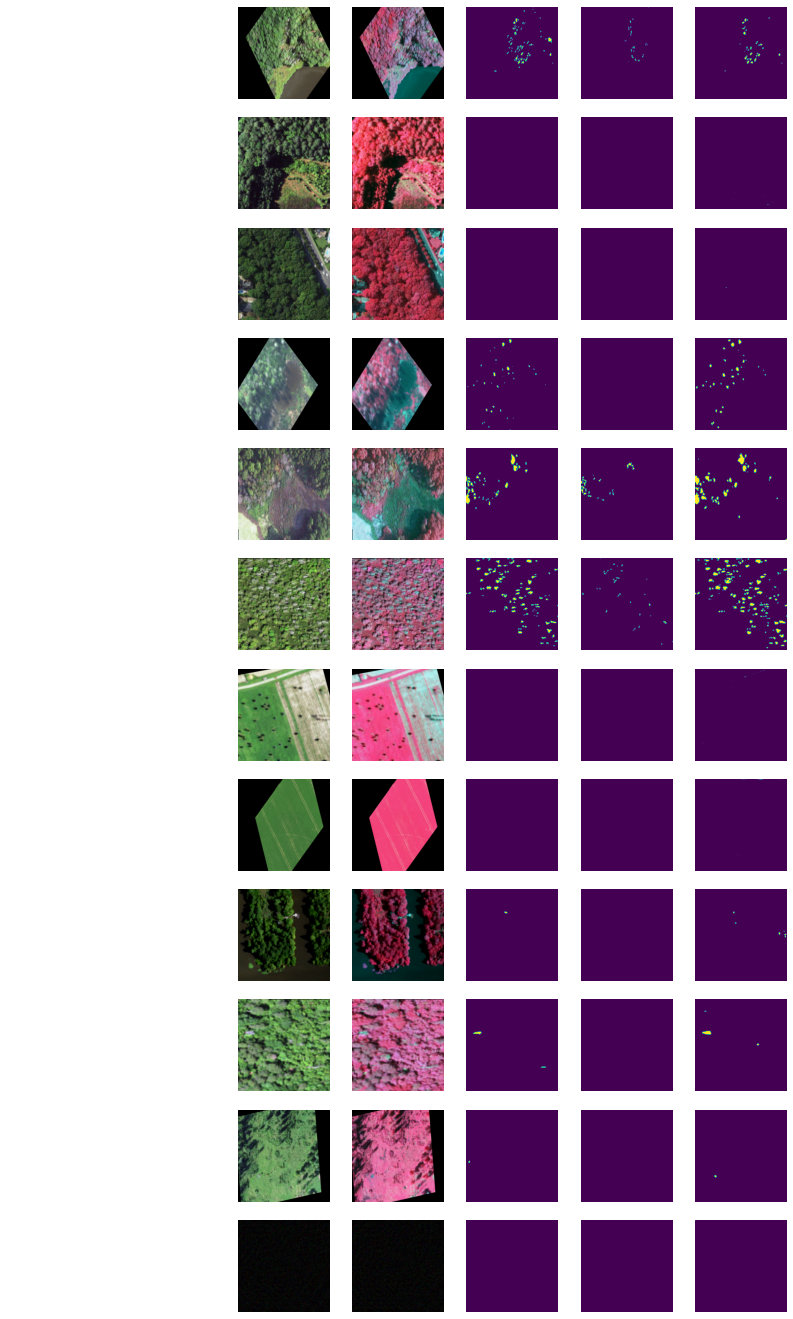

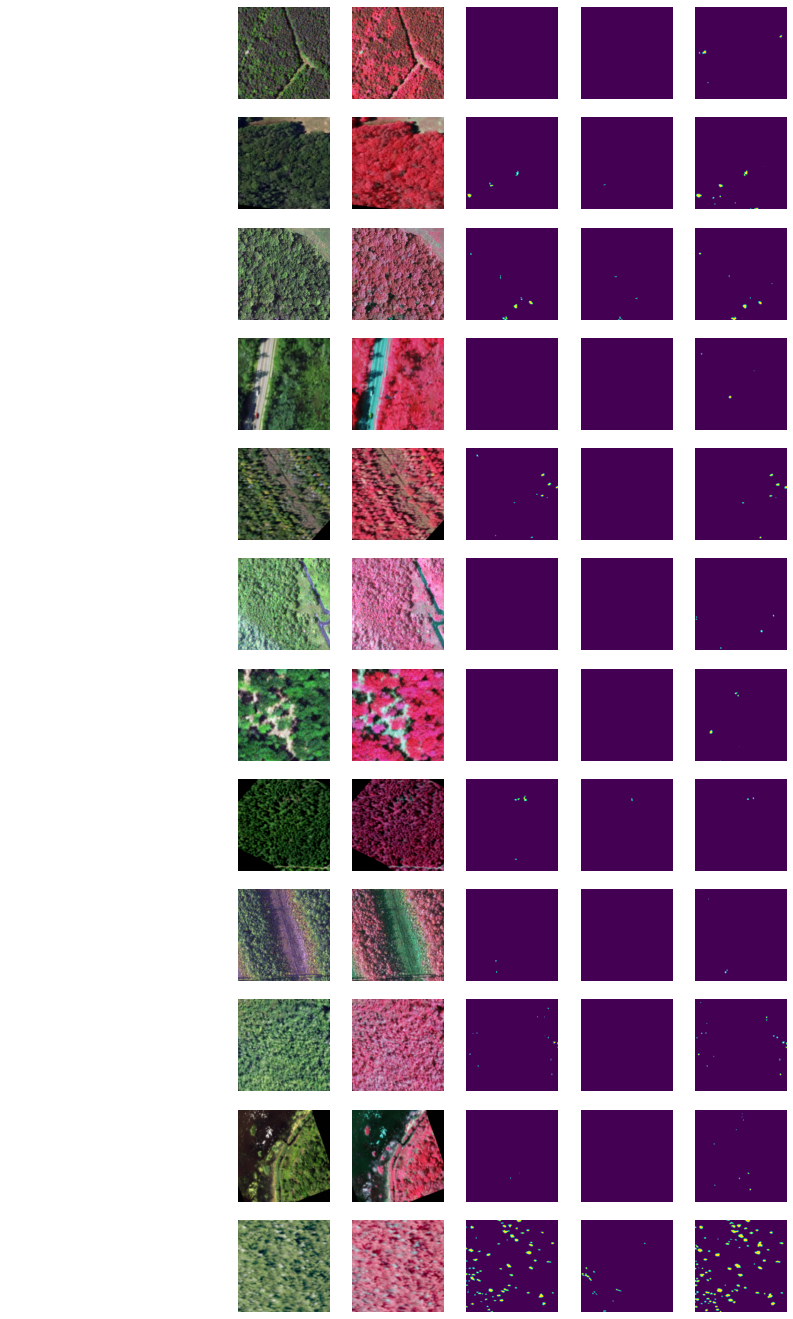

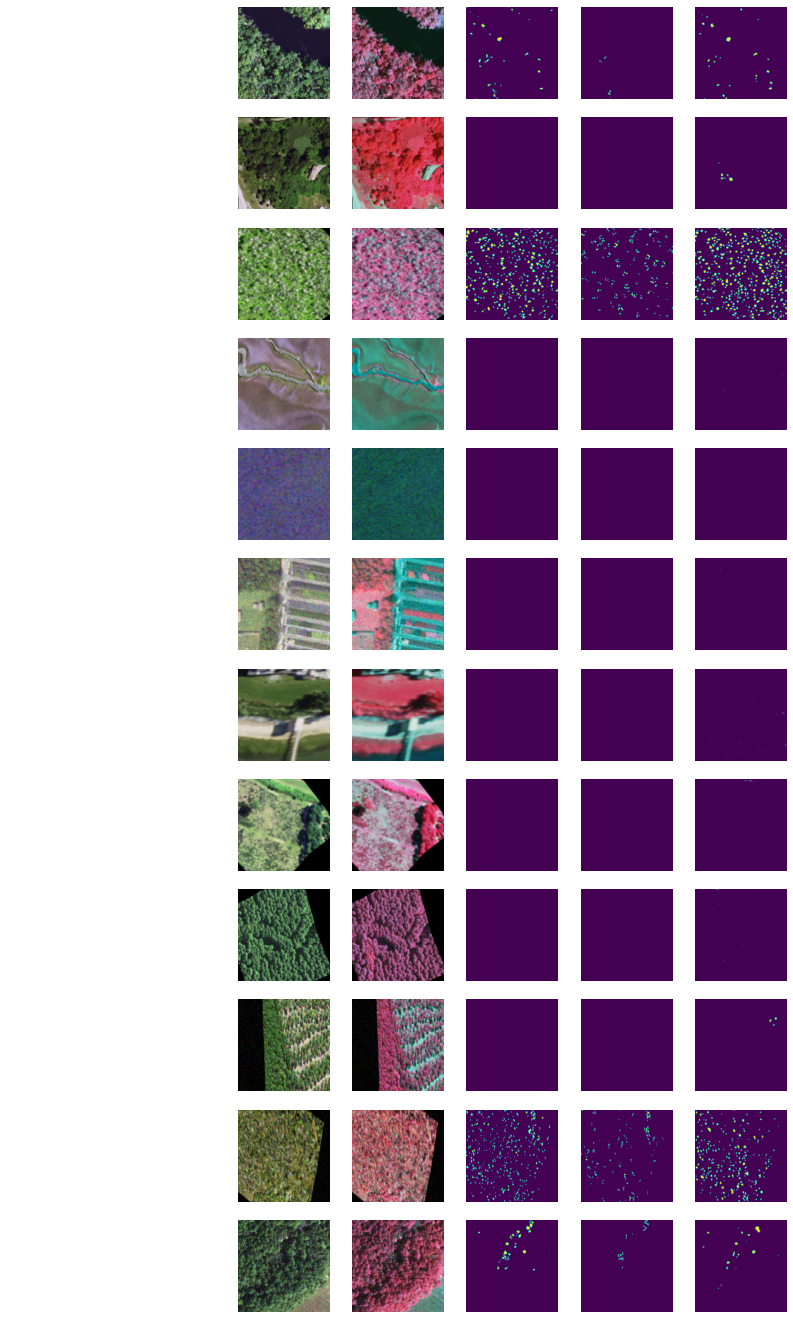

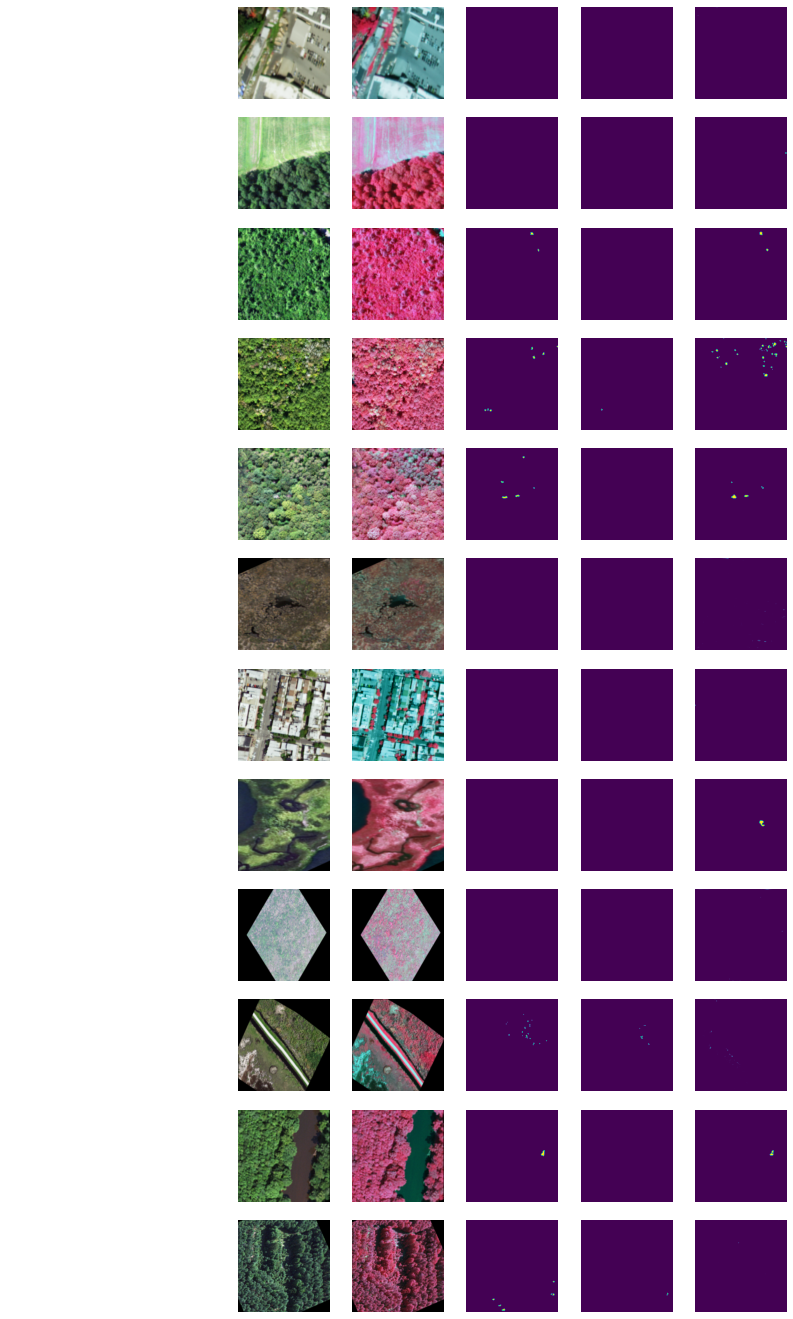

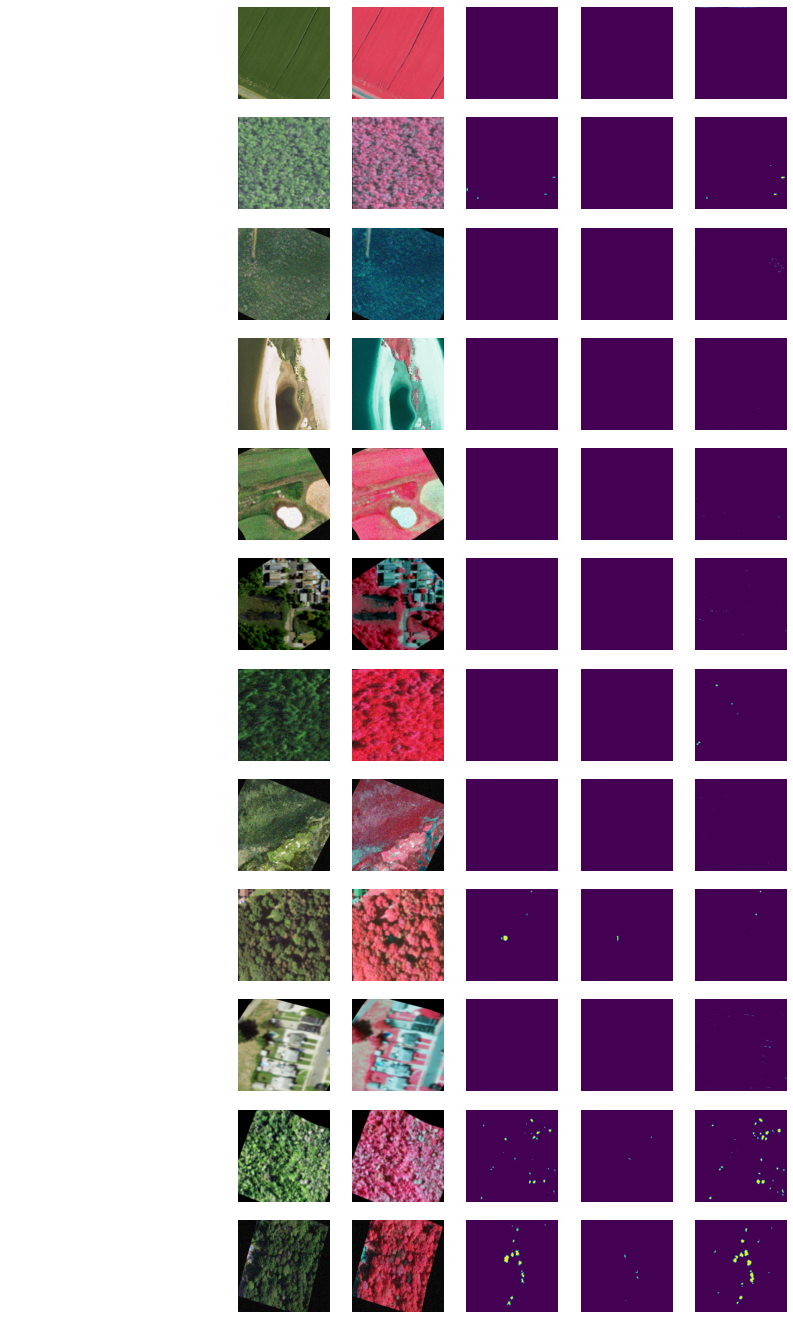

In [58]:
# Print one batch on the training/test data!
for i in range(5):
    test_images, real_label = next(train_generator)
    #5 images per row: pan, ndvi, label, weight, prediction
    prediction = new_model.predict(test_images, steps=1)
#     prediction[prediction>0.5]=1
#     prediction[prediction<=0.5]=0
    # display_images(np.concatenate((test_images[...,[0,1,3]],real_label, prediction), axis = -1), vmax=1, vmin=0)
    display_images(np.concatenate((test_images[...],real_label, prediction), axis = -1), colored=True)